<a href="https://colab.research.google.com/github/winzepz/Artificial-Intelligence-and-Machine-Learning/blob/main/MCP_and_0_vs_1_Classification-W3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
# =========================================
# MCP NEURON - AND FUNCTION
# =========================================

def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2), "Input lengths must match"

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Input values
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# Threshold for AND
T_and = 2

# Call function
and_result = MCP_Neurons_AND(X1, X2, T_and)

# Output
print("AND Gate Output:", and_result)

AND Gate Output: [0, 0, 0, 1]


In [ ]:
print("\nAND Truth Table:")
print("X1 X2 | AND")

for i in range(len(X1)):
    print(X1[i], X2[i], " | ", and_result[i])


AND Truth Table:
X1 X2 | AND
0 0  |  0
0 1  |  0
1 0  |  0
1 1  |  1


In [ ]:
# =========================================
# MCP NEURON - OR FUNCTION
# =========================================

def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2), "Input lengths must match"

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Threshold for OR
T_or = 1

# Call function
or_result = MCP_Neurons_OR(X1, X2, T_or)

# Output
print("OR Gate Output:", or_result)

OR Gate Output: [0, 1, 1, 1]


In [ ]:
print("\nOR Truth Table:")
print("X1 X2 | OR")

for i in range(len(X1)):
    print(X1[i], X2[i], " | ", or_result[i])


OR Truth Table:
X1 X2 | OR
0 0  |  0
0 1  |  1
1 0  |  1
1 1  |  1


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Correct path
file_path = "/content/drive/MyDrive/Colab Notebooks/AI and Machine Learning/Week3/mnist_0_and_1.csv"

# Load data
df_0_1 = pd.read_csv(file_path)

# Features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

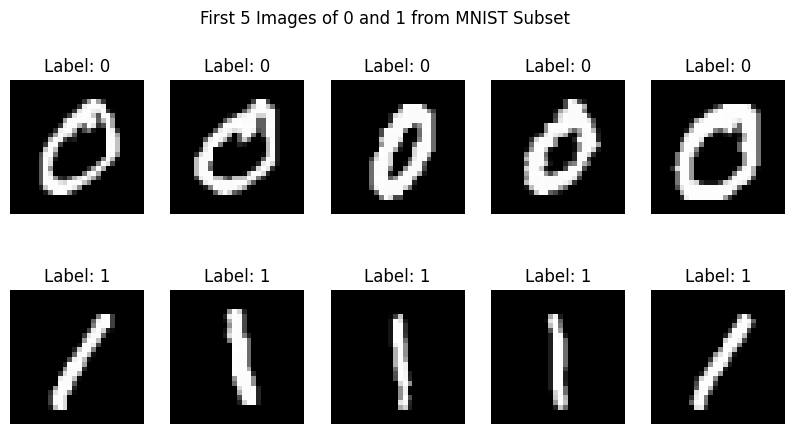

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 1000

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    """

    predictions = np.dot(X, weights) + bias

    # Step activation function
    y_pred_all = []

    for value in predictions:
        if value >= 0:
            y_pred_all.append(1)
        else:
            y_pred_all.append(0)

    return np.array(y_pred_all)

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias

            if z >= 0:
                y_pred = 1
            else:
                y_pred = 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        print(f"Epoch {epoch+1}/{epochs}, Correct: {correct}")

    accuracy = correct / len(X)

    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 1/100, Correct: 12623
Epoch 2/100, Correct: 12642
Epoch 3/100, Correct: 12648
Epoch 4/100, Correct: 12648
Epoch 5/100, Correct: 12652
Epoch 6/100, Correct: 12656
Epoch 7/100, Correct: 12662
Epoch 8/100, Correct: 12659
Epoch 9/100, Correct: 12651
Epoch 10/100, Correct: 12655
Epoch 11/100, Correct: 12659
Epoch 12/100, Correct: 12662
Epoch 13/100, Correct: 12665
Epoch 14/100, Correct: 12665
Epoch 15/100, Correct: 12665
Epoch 16/100, Correct: 12665
Epoch 17/100, Correct: 12665
Epoch 18/100, Correct: 12665
Epoch 19/100, Correct: 12665
Epoch 20/100, Correct: 12665
Epoch 21/100, Correct: 12665
Epoch 22/100, Correct: 12665
Epoch 23/100, Correct: 12665
Epoch 24/100, Correct: 12665
Epoch 25/100, Correct: 12665
Epoch 26/100, Correct: 12665
Epoch 27/100, Correct: 12665
Epoch 28/100, Correct: 12665
Epoch 29/100, Correct: 12665
Epoch 30/100, Correct: 12665
Epoch 31/100, Correct: 12665
Epoch 32/100, Correct: 12665
Epoch 33/100, Correct: 12665
Epoch 34/100, Correct: 12665
Epoch 35/100, Correct: 

## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!
